# Day 5: Probability: distributions and expectation

**Sat, Oct 10 · Prep · about 90 minutes**

Quantum computers don't hand you a single answer; they hand you samples from a probability distribution. Today you connect amplitudes (Days 1–2) to probabilities and to what you actually see when you run a circuit.

**By the end of this notebook you can:**
- Describe a discrete probability distribution and check it's normalised
- Compute an expected value and a variance
- Turn complex amplitudes into probabilities with the Born rule
- Simulate repeated measurements and watch counts converge

> How to use this notebook: read each explanation, run the cell under it, then change the numbers and run it again.
> The exercises at the end have a "your turn" cell and a hidden worked solution. Try first, then check.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (5, 5), "axes.grid": True, "grid.alpha": 0.3})

def tex(label):
    """Typeset a ket label like '|+>' as a proper |+⟩ in plots."""
    if label.startswith("|") and label.endswith(">"):
        return r"$|" + label[1:-1] + r"\rangle$"
    return label
rng = np.random.default_rng(7)

## Symbols in this notebook
Not sure how to read something? Here's every symbol used below, with how to say it. The full dictionary is in [Day 0](00_reading_maths_symbols.ipynb).

| Symbol | Say it | Means |
|---|---|---|
| P(A) | "probability of A" | a number from 0 (never) to 1 (always) |
| pₖ | "p sub k" | the probability of outcome k |
| Σₖ pₖ = 1 | "the sum of all p sub k is one" | probabilities must add to 1 |
| X | "X" | a random variable: a quantity whose value comes out at random |
| E[X] | "expected value of X" | the long-run average, Σ xₖ pₖ |
| Var[X] | "variance of X" | spread: E[X²] − E[X]² |
| α, β | "alpha", "beta" | the amplitudes of \|0⟩ and \|1⟩ |
| \|α\|² | "mod alpha squared" | the probability of measuring 0 (Born rule) |
| ⟨Z⟩ | "expectation value of Z" | average result when outcomes are labelled +1 and −1 |

## Back to basics: probability from scratch
A **probability** is a number between 0 and 1 saying how likely something is: 0 means impossible, 1 means certain, 0.5 means half the time.

**Basic rules, with a coin and a die:**
- **Equally likely outcomes:** P = (number of ways it can happen) / (total number of outcomes). A fair die: P(rolling a 4) = 1/6.
- **"Not":** P(not A) = 1 − P(A). P(not a 4) = 1 − 1/6 = 5/6.
- **"Or", when they can't both happen:** add. P(1 or 2) = 1/6 + 1/6 = 1/3.
- **"And", for independent events:** multiply. Two coin flips, P(heads and heads) = 1/2 × 1/2 = 1/4.

**Percentages and decimals:** 0.25 = 25% = 1/4. In quantum computing results, you'll see all three.

In [2]:
from fractions import Fraction as F
print("P(4) =", F(1, 6), "  P(not 4) =", 1 - F(1, 6), "  P(1 or 2) =", F(1, 6) + F(1, 6), "  P(HH) =", F(1, 2) * F(1, 2))

P(4) = 1/6   P(not 4) = 5/6   P(1 or 2) = 1/3   P(HH) = 1/4


## 1. Discrete distributions
A distribution lists outcomes and their probabilities. Two rules: every probability is ≥ 0, and they **sum to 1**.

sums to 1? True


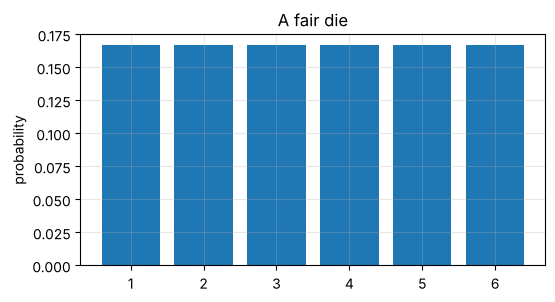

In [3]:
outcomes = np.array([1, 2, 3, 4, 5, 6])
p = np.full(6, 1 / 6)
print("sums to 1?", np.isclose(p.sum(), 1))
plt.figure(figsize=(6, 3)); plt.bar(outcomes, p); plt.title("A fair die"); plt.ylabel("probability"); plt.show()

## 2. Expected value and variance
**E[X] = Σ xₖ pₖ** is the long-run average: the balance point of the distribution.
**Var[X] = E[X²] − E[X]²** measures spread.

E[X] = 3.5000, Var[X] = 2.9167


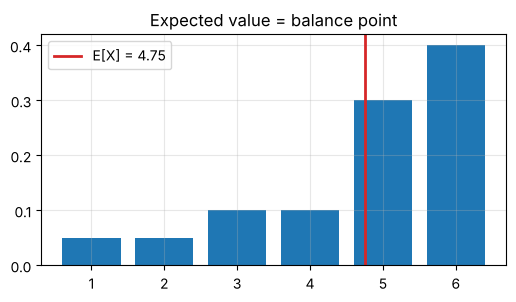

In [4]:
E = (outcomes * p).sum(); Var = (outcomes**2 * p).sum() - E**2
print(f"E[X] = {E:.4f}, Var[X] = {Var:.4f}")

skewed = np.array([0.05, 0.05, 0.1, 0.1, 0.3, 0.4])
E2 = (outcomes * skewed).sum()
plt.figure(figsize=(6, 3)); plt.bar(outcomes, skewed); plt.axvline(E2, color="C3", lw=2, label=f"E[X] = {E2:.2f}")
plt.title("Expected value = balance point"); plt.legend(); plt.show()

## 3. The Born rule: amplitudes → probabilities
A qubit state α|0⟩ + β|1⟩ is measured as 0 with probability **|α|²** and as 1 with probability **|β|²**.
Phases don't change these probabilities: α = 1/√2 and α = i/√2 both give 1/2.

probabilities: [0.5 0.5]  sum: 0.9999999999999998


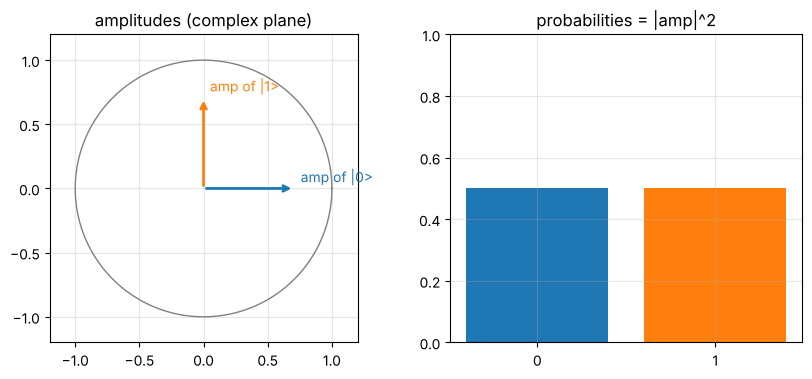

In [5]:
amps = np.array([1 / np.sqrt(2), 1j / np.sqrt(2)])
probs = np.abs(amps) ** 2
print("probabilities:", probs, " sum:", probs.sum())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
t = np.linspace(0, 2 * np.pi, 200); a1.plot(np.cos(t), np.sin(t), color="gray", lw=1)
for k, (amp, c) in enumerate(zip(amps, ["C0", "C1"])):
    a1.annotate("", xy=(amp.real, amp.imag), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2))
    a1.text(amp.real + 0.05, amp.imag + 0.05, f"amp of |{k}>", color=c)
a1.set_aspect("equal"); a1.set_xlim(-1.2, 1.2); a1.set_ylim(-1.2, 1.2); a1.set_title("amplitudes (complex plane)")
a2.bar(["0", "1"], probs, color=["C0", "C1"]); a2.set_ylim(0, 1); a2.set_title("probabilities = |amp|^2")
plt.show()

## 4. What you actually see: sampling
Run the "circuit" N times and count outcomes. With more shots, the observed frequencies settle on the true probabilities.
This is why real quantum results are reported as **counts**, e.g. `{'0': 507, '1': 493}`.

    10 shots -> freq of 0 = 0.700  (true 0.8)
   100 shots -> freq of 0 = 0.810  (true 0.8)
  1000 shots -> freq of 0 = 0.802  (true 0.8)
 10000 shots -> freq of 0 = 0.793  (true 0.8)


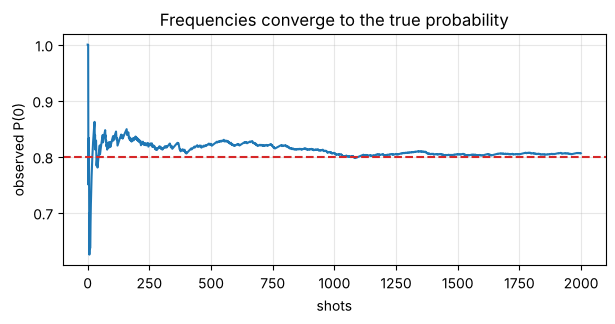

In [6]:
probs = np.array([0.8, 0.2])
for shots in [10, 100, 1000, 10000]:
    samples = rng.choice([0, 1], size=shots, p=probs)
    print(f"{shots:>6} shots -> freq of 0 = {np.mean(samples == 0):.3f}  (true 0.8)")

running = np.cumsum(rng.choice([0, 1], size=2000, p=probs) == 0) / np.arange(1, 2001)
plt.figure(figsize=(7, 3)); plt.plot(running); plt.axhline(0.8, color="C3", ls="--")
plt.xlabel("shots"); plt.ylabel("observed P(0)"); plt.title("Frequencies converge to the true probability"); plt.show()

## 5. Expected value of a measurement
If outcome 0 is labelled +1 and outcome 1 is labelled −1, then E = (+1)·P(0) + (−1)·P(1) = P(0) − P(1).
This is the **expectation value ⟨Z⟩** you'll compute constantly in variational algorithms (Module 8).

## Worked example, every step shown: expected value and variance of a weighted die
A die has P(1) = 0.5, P(2) = 0.3, P(3) = 0.2. Find E[X] and Var[X].

**Read it aloud:** E[X] = Σ xₖ pₖ, "the expected value of X is the sum of each value times its probability".

1. Check it's a valid distribution: 0.5 + 0.3 + 0.2 = 1.0 ✓
2. E[X] = 1(0.5) + 2(0.3) + 3(0.2) = 0.5 + 0.6 + 0.6 = **1.7**
3. E[X²] = 1²(0.5) + 2²(0.3) + 3²(0.2) = 0.5 + 1.2 + 1.8 = 3.5
4. Var[X] = E[X²] − E[X]² = 3.5 − 1.7² = 3.5 − 2.89 = **0.61**

In [7]:
x = np.array([1, 2, 3]); p = np.array([0.5, 0.3, 0.2])
E = (x * p).sum(); E2 = (x**2 * p).sum()
print("E[X] =", E, "  E[X^2] =", E2, "  Var =", round(E2 - E**2, 4))

E[X] = 1.7000000000000002   E[X^2] = 3.5   Var = 0.61


## Worked example, every step shown: the Born rule with a complex amplitude
A qubit is in the state (3/5)|0⟩ + (4i/5)|1⟩. What are P(0), P(1) and ⟨Z⟩?

1. α = 3/5, so |α|² = (3/5)² = 9/25 = **0.36**
2. β = 4i/5, so |β| = 4/5 (the i only rotates it, it doesn't change the length) and |β|² = 16/25 = **0.64**
3. Check: 0.36 + 0.64 = 1 ✓
4. ⟨Z⟩ = (+1)(0.36) + (−1)(0.64) = **−0.28**. Negative, because 1 is the more likely outcome.

In [8]:
amps = np.array([3 / 5, 4j / 5]); p = np.abs(amps)**2
print("P(0), P(1) =", p, "  <Z> =", p[0] - p[1])

P(0), P(1) = [0.36 0.64]   <Z> = -0.28000000000000014


### Common mistakes
- Squaring the amplitude instead of its modulus. (i/√2)² = −1/2, which can't be a probability; |i/√2|² = 1/2 is correct.
- Forgetting that the probabilities must add to 1. If they don't, the state wasn't normalised.
- Expecting exact 50/50 counts from a finite number of shots. Real counts wobble around the true value.

## Exercises
**E1.** For amplitudes (1/√2, i/√2), give P(0) and P(1).

**E2.** With outcome values +1 for 0 and −1 for 1, compute the expected value for E1's state.

**E3.** A state has amplitudes (√3/2, 1/2). Compute P(0), P(1) and the ±1 expected value. Then simulate 5000 shots and compare.

In [9]:
# Your turn

<details>
<summary><b>Show worked solution</b></summary>

**E1.** P(0) = |1/√2|² = 1/2, P(1) = |i/√2|² = |i|²/2 = 1/2.

**E2.** E = (+1)(1/2) + (−1)(1/2) = 0.

**E3.** P(0) = 3/4, P(1) = 1/4, E = 3/4 − 1/4 = 1/2. With 5000 shots expect about 3750 zeros, give or take ~30.

</details>

In [10]:
amps = np.array([1, 1j]) / np.sqrt(2); pr = np.abs(amps) ** 2
assert np.allclose(pr, [0.5, 0.5]) and np.isclose(pr[0] - pr[1], 0)
amps = np.array([np.sqrt(3) / 2, 1 / 2]); pr = np.abs(amps) ** 2
assert np.allclose(pr, [0.75, 0.25]) and np.isclose(pr[0] - pr[1], 0.5)
s = rng.choice([1, -1], size=5000, p=pr)
print("simulated E =", s.mean(), "(true 0.5)")
print("All Day 5 checks passed.")

simulated E = 0.492 (true 0.5)
All Day 5 checks passed.


---
### Recap checklist
Tick these off in your head before moving on. If any feel shaky, re-run the relevant section with your own numbers.

**Next:** Day 6: AI/ML maths bridge

*Part of the IIT Delhi CEP Applied Quantum Computing & AI prep plan: [prep-plan.md](../plan/prep-plan.md)*